Exploratory Data Analysis of EEOC1 Data. Completed Tables are at the Bottom

In [1]:
import pandas as pd
import dtale
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_dir = Path('EEOC_Data/EEOC1_Cleaned_Master_v3.0')

nat_raw    = pd.read_csv(data_dir / 'EEOC1_National_Baselines.csv')
state_raw  = pd.read_csv(data_dir / 'EEOC1_State_Totals.csv')
county_raw = pd.read_csv(data_dir / 'EEOC1_County_Totals.csv')
cbsa_raw   = pd.read_csv(data_dir / 'EEOC1_CBSA_Total.csv')
demogr_raw = pd.read_csv(data_dir / 'EEOC1_Demogr_Total.csv')
master_raw = pd.read_csv(data_dir / 'Master.csv')

C:\Users\jfraz\AppData\Local\Temp\ipykernel_12620\885778031.py:8: DtypeWarning: Columns (0: REGION, 1: DIVISION, 2: STATE, 3: COUNTY) have mixed types. Specify dtype option on import or set low_memory=False.
  master_raw = pd.read_csv(data_dir / 'Master.csv')


In [3]:
nat_df = nat_raw.copy()
state_df = state_raw.copy()
county_df = county_raw.copy()
cbsa_df = cbsa_raw.copy()
demogr_df = demogr_raw.copy()
master_df = master_raw.copy()

In [4]:
nat_df.pivot_table(
    values= ['WHT10', 'BLKT10', 'HISPT10'],
    index= 'YEAR'
)

,BLKT10,HISPT10,WHT10
YEAR,,,
2014,308705.375000,294423.250000,1.347848e+06
2015,321984.625000,306982.208333,1.354920e+06
2016,337610.625000,324945.125000,1.379877e+06
2017,344733.333333,337874.125000,1.366697e+06
2018,355983.916667,360085.041667,1.386802e+06
2019,381553.434783,392854.304348,1.450701e+06
2020,358669.130435,379573.434783,1.379894e+06
2021,388953.521739,425002.043478,1.447472e+06
2022,506397.695652,586931.652174,1.843877e+06


In [5]:
total_wht = nat_df['WHT10'].sum()
total_wht

np.float64(347613495.0)

In [6]:
total_demo_wht = demogr_df['WHT10'].sum()
total_demo_wht

np.float64(347613495.0)

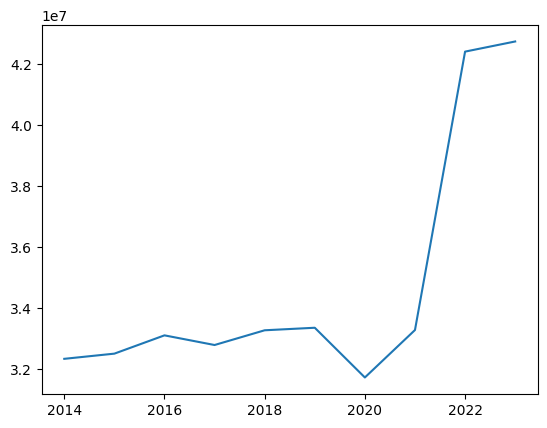

In [7]:
#first attempt at a line plot
plt.plot(demogr_df['YEAR'], demogr_df['WHT10'])

The Data set above shows that there was a huge jump in employment numbers from 2022-2023. This is due to the EEOC eleminating type 6 reporting. In order to account for this chamge in historical analysis, I'll switch to using proportions of the workforce instead of totals. 

(0.0, 100.0)

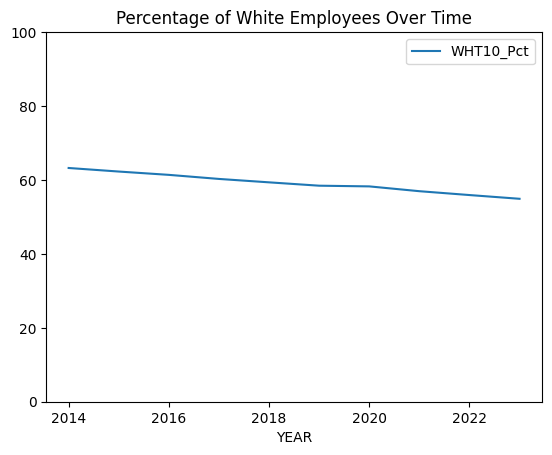

In [8]:
#Using 'TOTAL10' as the columns total workforce, I will create a new column to show the percentage of workers. 
demogr_df['WHT10_Pct'] = (demogr_df['WHT10'] / demogr_df['TOTAL10']) * 100

# Now plot the percentage over time
demogr_df.plot(
    x='YEAR', 
    y='WHT10_Pct', 
    kind='line', 
    title='Percentage of White Employees Over Time',
)
plt.ylim(0, 100) # Sets the Y-axis to scale from 0% to 100%


(0.0, 100.0)

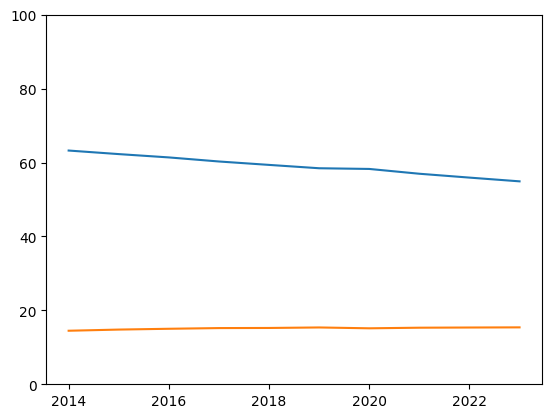

In [9]:
plt.plot(demogr_df['YEAR'], demogr_df['WHT10_Pct'], label='White')
plt.plot(demogr_df['YEAR'], demogr_df['BLKT10_Pct'], label='Black')
plt.ylim(0, 100)


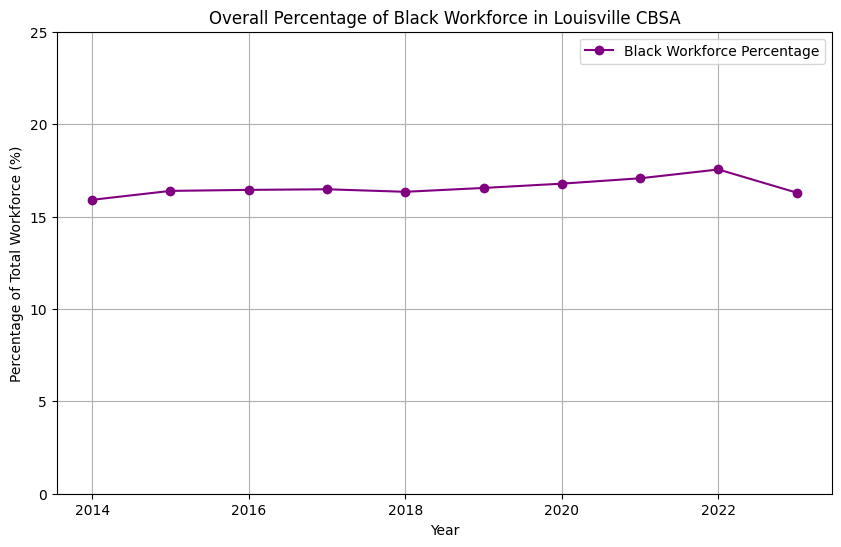

In [10]:
louisville_df = cbsa_df[cbsa_df['CBSA'].str.contains('Louisville', case=False, na=False)].copy()

# Group by 'YEAR' and sum up the raw counts across all industries
louisville_grouped = louisville_df.groupby('YEAR')[['TOTAL10', 'BLKT10']].sum().reset_index()

# Recalculate the percentage using those new grand totals
louisville_grouped['BLKT10_Pct'] = (louisville_grouped['BLKT10'] / louisville_grouped['TOTAL10']) * 100


plt.figure(figsize=(10, 6))


plt.plot(louisville_grouped['YEAR'], louisville_grouped['BLKT10_Pct'], marker='o', color='purple', label='Black Workforce Percentage')

# Add titles and labels
plt.title('Overall Percentage of Black Workforce in Louisville CBSA')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Workforce (%)')

# Adjust the Y-axis based on the new aggregated data
plt.ylim(0, 25) 
plt.legend()
plt.grid(True)


plt.show()

Below I'm going to play around with Heatmaps to see if anything stands out.

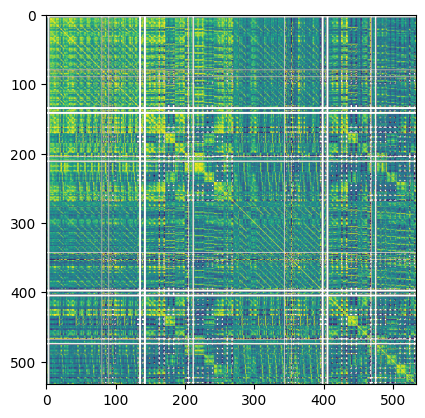

In [11]:
numeric_Louisville_df = louisville_df.select_dtypes(include= [np.number])
corr = numeric_Louisville_df.corr()
plt.imshow(corr)


In [12]:
d= dtale.show(numeric_Louisville_df)
d.open_browser()

In [13]:
"""
I need make my DF smaller, I want to only keep my Percent columns (PCT). 
I need to drop all of the numeric columns preceding "WHT10_Pct"
"""

df = numeric_Louisville_df
WHT10_Pct = list(df.columns).index('WHT10_Pct')
print(WHT10_Pct)

270


In [14]:
#Find the column index of the first column I need to drop
df = numeric_Louisville_df
Total10 = list(df.columns).index('TOTAL10')
print(Total10)

6


In [15]:
#Drop columns 6-269
num_pct_Louisville_df = df.drop(df.columns[6:270], axis=1)
d= dtale.show(num_pct_Louisville_df)
d.open_browser()

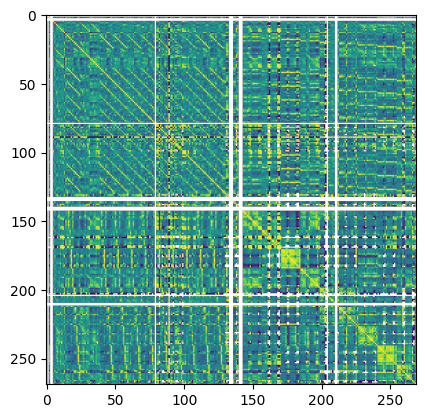

In [16]:
corr = num_pct_Louisville_df.corr()
plt.imshow(corr)

The Heat Map above is neater in DTale and easier to identify correlations. 

Below I am making a heat map looking only at the National demographic totals.

In [17]:
#Finiding the stating index of columns I need to keep
df = demogr_df
WHT10_Pct = list(df.columns).index('WHT10_Pct')
print(WHT10_Pct)

276


In [18]:
#Finding the column index of columns I can delete
Nation = list(df.columns).index('NATION')
print(Nation)

1


In [19]:
#Checking out my new df in Dtale
num_pct_demo_df = df.drop(df.columns[1:276], axis=1)
d= dtale.show(num_pct_demo_df)
d.open_browser()

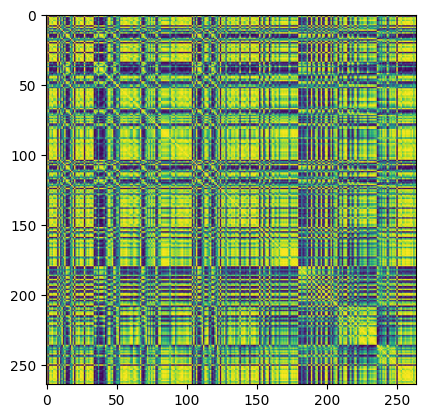

In [20]:
corr = num_pct_demo_df.corr()
plt.imshow(corr)

This Heatmap looks at correlations within the Demogrhic Data Set, containing the national level total aggregate demographic variables by year.
- I chose a heatmap because it is easier to identify stong correlations that are both positive and negative, within a large dataset with many variables. 
- From our class examples, I chose to go with the coolwarm colorset, but I inversed the colors so that red would be associated with a negative correlation and blue with positive correlations.

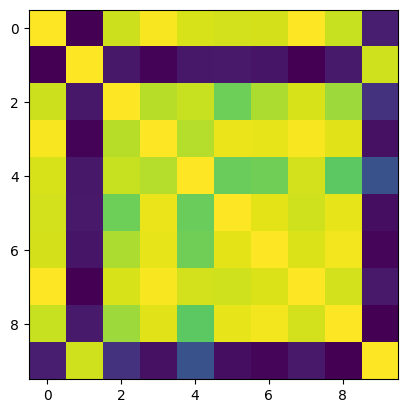

In [21]:
#Creating a Heatmap of showing the trend of aggregated National Demographic Totals Employed by Year
Total_Dem_Columns = ['YEAR', 'WHT10_Pct', 'BLKT10_Pct', 'HISPT10_Pct', 'ASIANT10_Pct', 'AIANT10_Pct',
                      'NHOPIT10_Pct', 'TOMRT10_Pct', 'FEMALE_TOTAL_Pct', 'MALE_TOTAL_Pct'  ]
corr_plot = df[Total_Dem_Columns].corr()
plt.imshow(corr_plot)

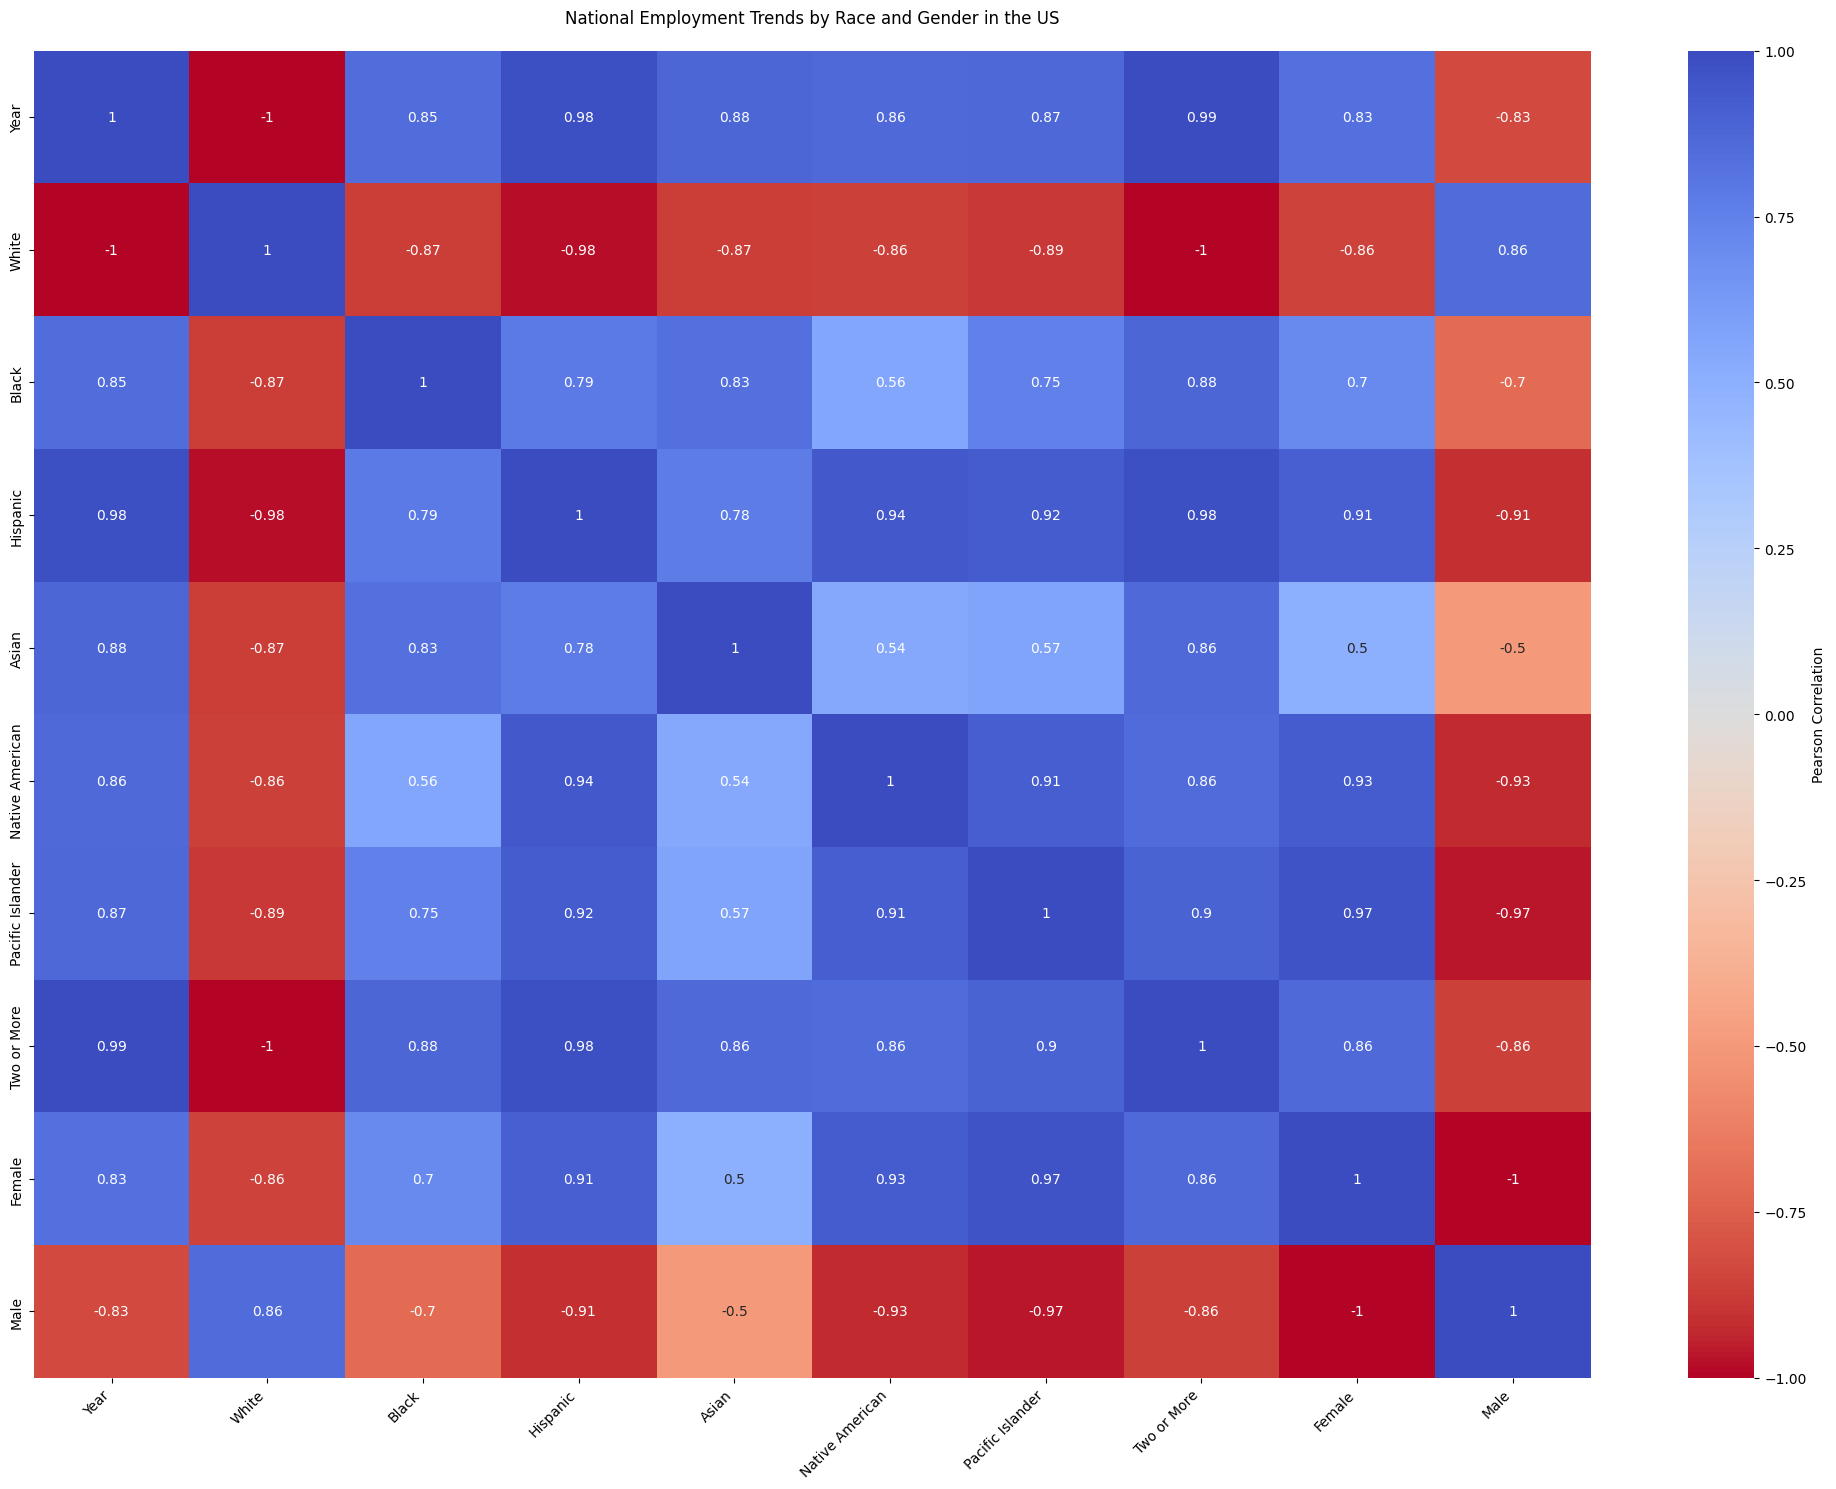

<Figure size 1000x600 with 0 Axes>

In [22]:
#Tidying up the Heatmap
import seaborn as sns


corr_plot = df[Total_Dem_Columns].corr()

#Rename the labels for readability
new_labels = ['Year', 'White', 'Black', 'Hispanic', 'Asian', 'Native American', 'Pacific Islander', 'Two or More', 'Female', 'Male']

plt.figure(figsize=(20,15))

sns.heatmap(corr_plot, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            cmap='coolwarm_r',
            cbar_kws={'label': 'Pearson Correlation'}, 
            xticklabels= new_labels, 
            yticklabels= new_labels)

plt.xticks(rotation=45, ha='right')
plt.title('National Employment Trends by Race and Gender in the US', pad=20)

plt.tight_layout()
plt.figure(figsize=(10,6))

plt.show()

Now I am going to make the same heatmap as above, for Louisville, using the variables aggrated by Race and Gender combined.

In [23]:
d= dtale.show(num_pct_Louisville_df)
d.open_browser()

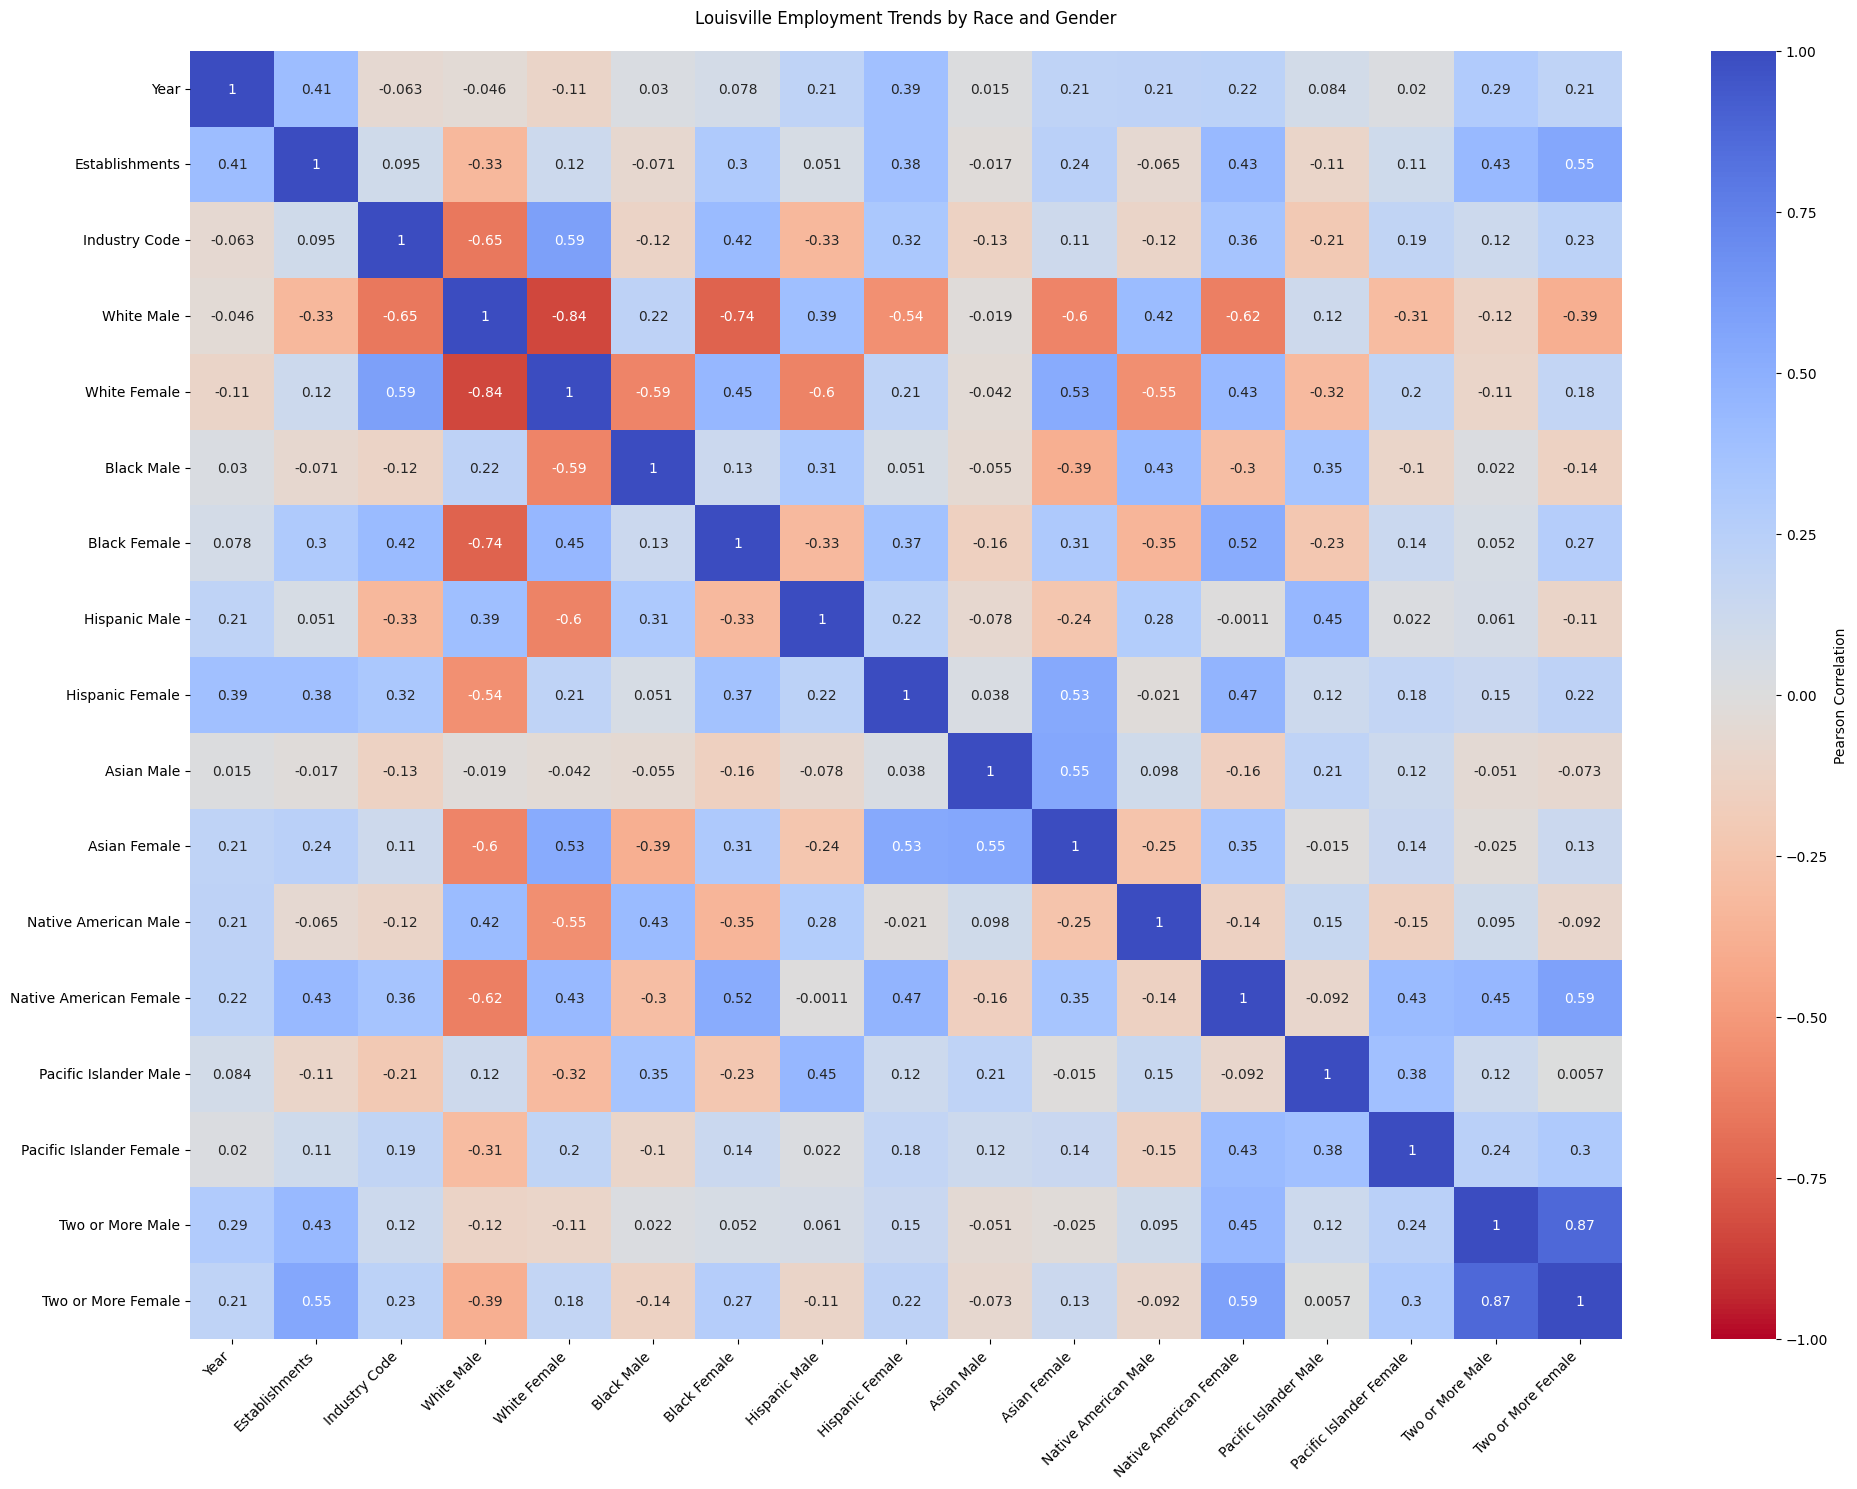

In [24]:
df = num_pct_Louisville_df
Lou_Columns = ['YEAR', 'ESTABLISHMENTS', 'NAICS2', 'WHM10_Pct', 'WHF10_Pct', 'BLKM10_Pct', 'BLKF10_Pct', 'HISPM10_Pct', 'HISPF10_Pct',
               'ASIANM10_Pct', 'ASIANF10_Pct','AIANM10_Pct', 'AIANF10_Pct', 'NHOPIM10_Pct', 'NHOPIF10_Pct',
               'TOMRM10_Pct', 'TOMRF10_Pct']

corr = df[Lou_Columns].corr()

#Tidying up the Heatmap
import seaborn as sns

#Rename the labels for readability
new_labels = ['Year', 'Establishments', 'Industry Code', 'White Male', 'White Female', 'Black Male', 'Black Female', 
              'Hispanic Male', 'Hispanic Female', 
              'Asian Male', 'Asian Female', 'Native American Male', 'Native American Female', 
              'Pacific Islander Male', 'Pacific Islander Female', 'Two or More Male', 'Two or More Female']

plt.figure(figsize=(20,15))

sns.heatmap(corr, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            cmap='coolwarm_r',
            cbar_kws={'label': 'Pearson Correlation'}, 
            xticklabels= new_labels, 
            yticklabels= new_labels)

plt.xticks(rotation=45, ha='right')
plt.title('Louisville Employment Trends by Race and Gender', pad=20)

plt.tight_layout()


plt.show()

Let's look at Louisville without splitting each variable by gender.

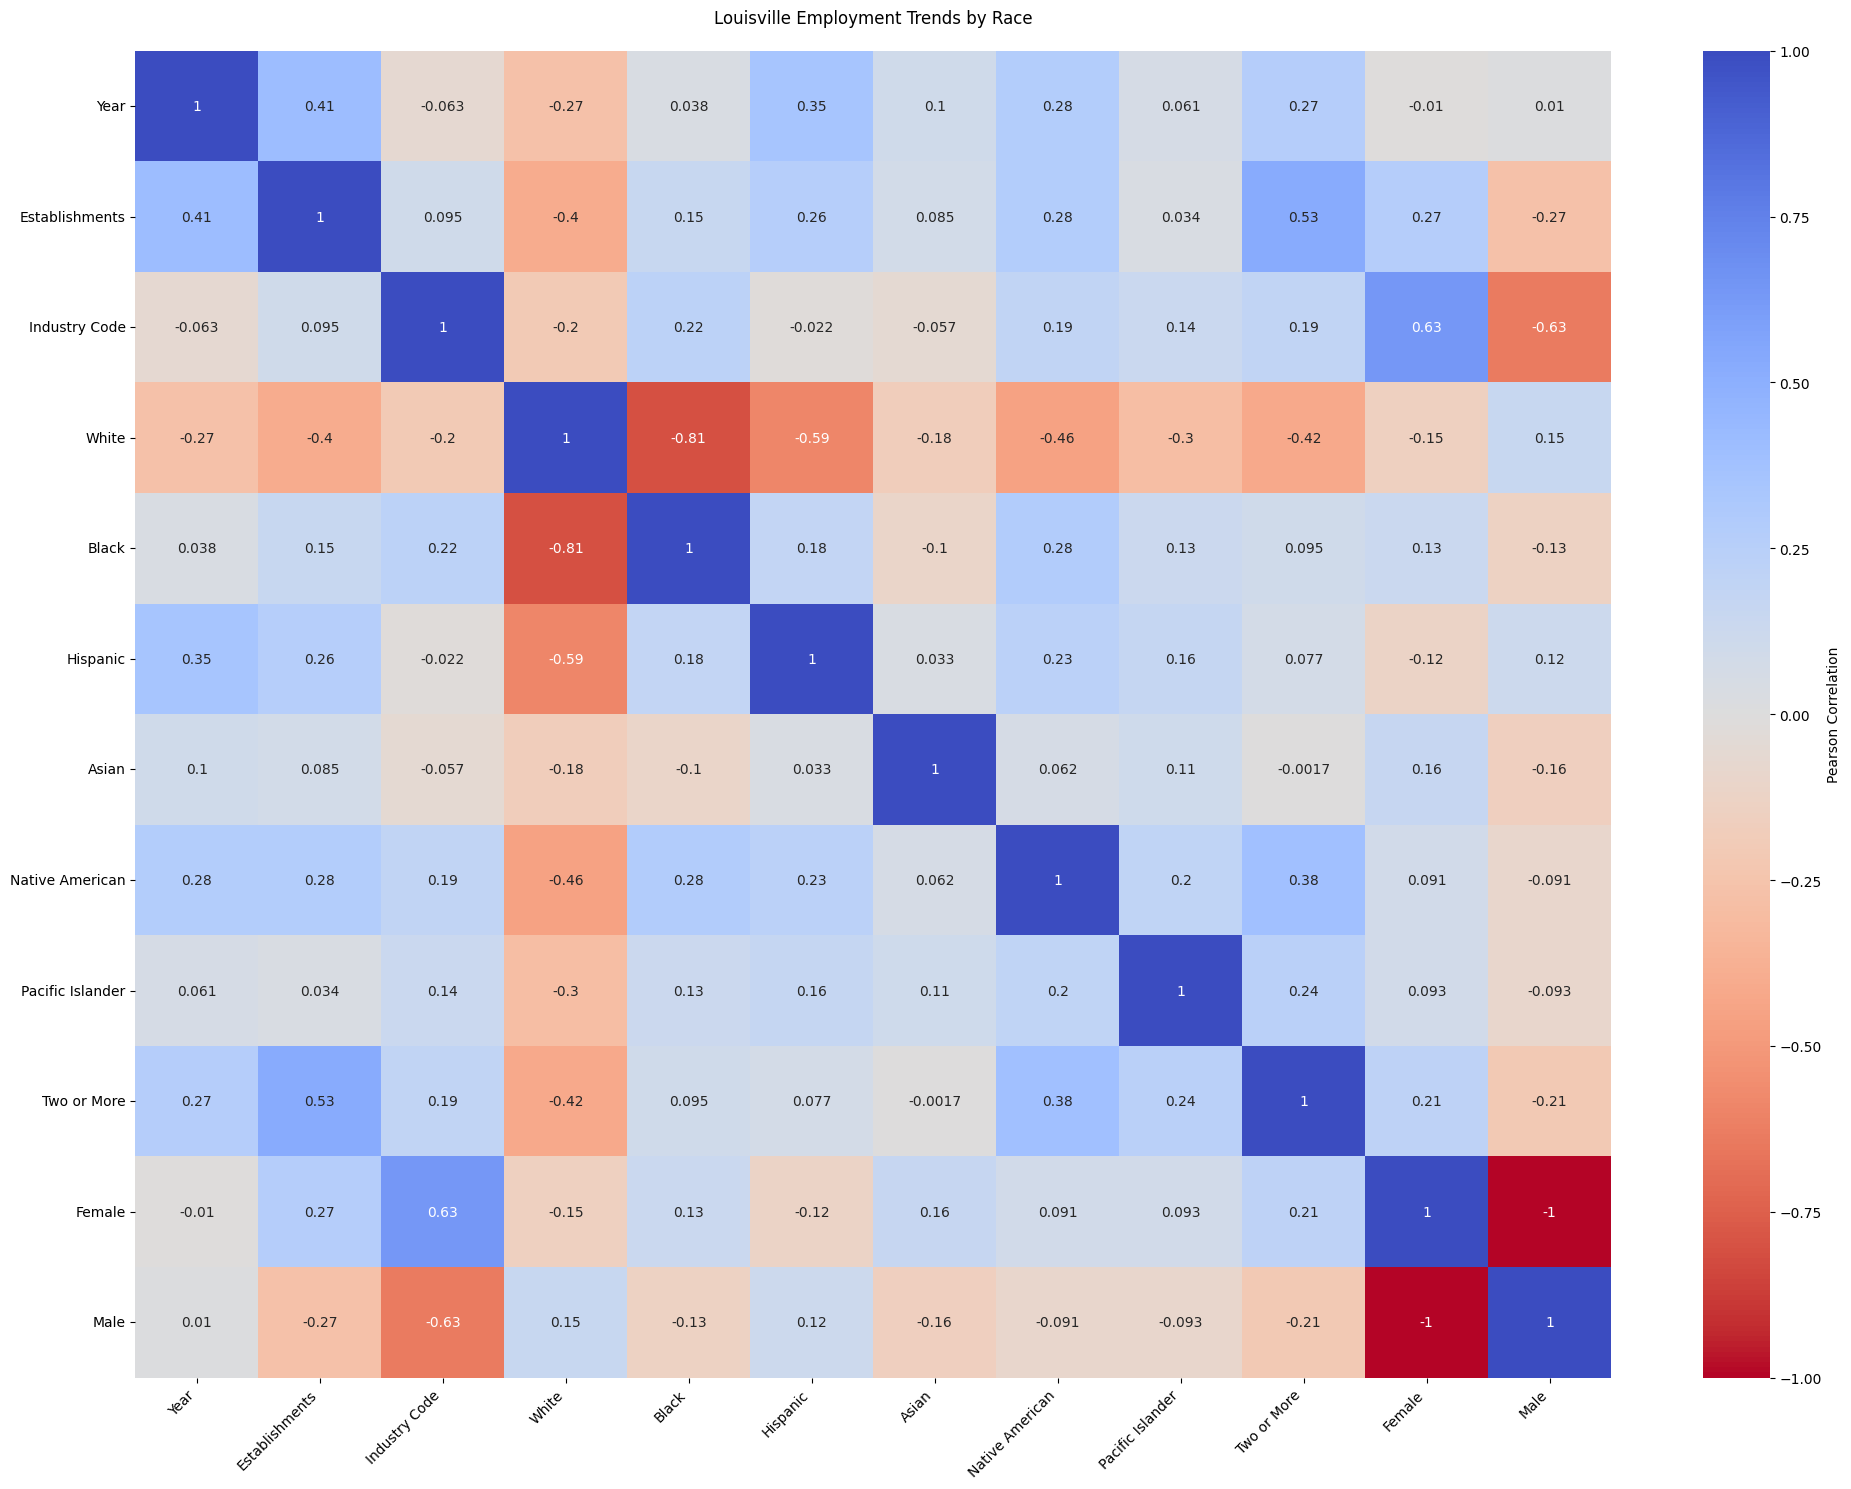

In [25]:
df = num_pct_Louisville_df
Lou_Columns = ['YEAR', 'ESTABLISHMENTS', 'NAICS2', 'WHT10_Pct', 'BLKT10_Pct', 'HISPT10_Pct', 'ASIANT10_Pct', 'AIANT10_Pct',
                      'NHOPIT10_Pct', 'TOMRT10_Pct', 'FEMALE_TOTAL_Pct', 'MALE_TOTAL_Pct']
corr = df[Lou_Columns].corr()

#Tidying up the Heatmap
import seaborn as sns

#Rename the labels for readability
new_labels = ['Year', 'Establishments', 'Industry Code', 'White', 'Black', 'Hispanic', 'Asian', 'Native American', 'Pacific Islander', 'Two or More', 'Female', 'Male']

plt.figure(figsize=(20,15))

sns.heatmap(corr, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            cmap='coolwarm_r',
            cbar_kws={'label': 'Pearson Correlation'}, 
            xticklabels= new_labels, 
            yticklabels= new_labels)

plt.xticks(rotation=45, ha='right')
plt.title('Louisville Employment Trends by Race', pad=20)

plt.tight_layout()


plt.show()

Are there any correlations in Louisivlle by Profession and Race?

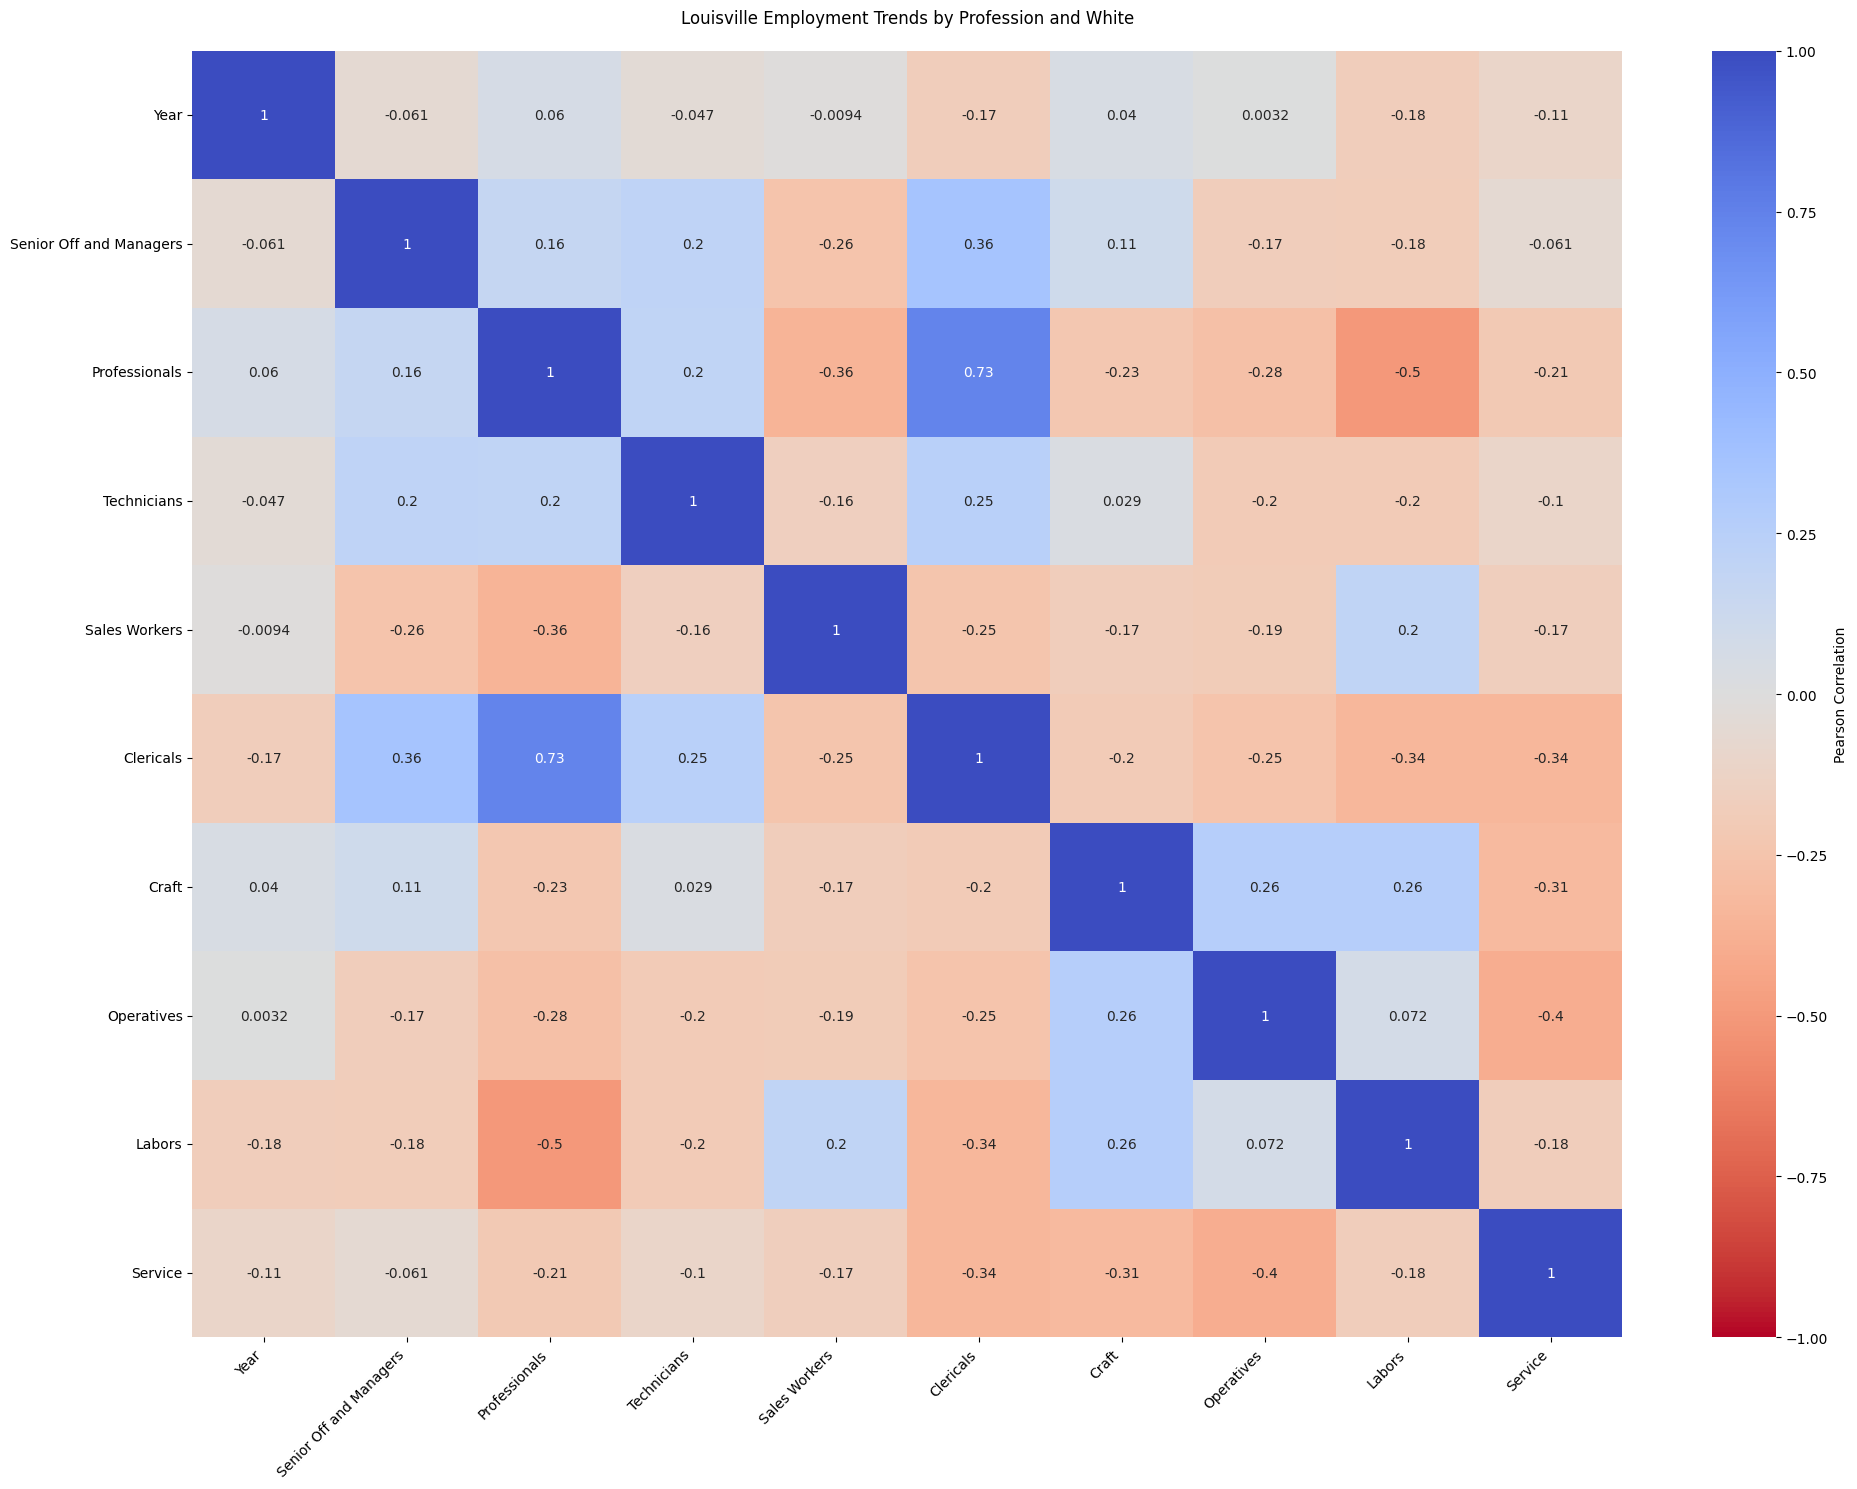

In [26]:
df = num_pct_Louisville_df
Lou_Columns = ['YEAR', 'WHT1_Pct', 'WHT2_Pct', 'WHT3_Pct', 'WHT4_Pct', 'WHT5_Pct', 'WHT6_Pct',
               'WHT7_Pct', 'WHT8_Pct', 'WHT9_Pct',]
corr = df[Lou_Columns].corr()

#Tidying up the Heatmap
import seaborn as sns

#Rename the labels for readability
new_labels = ['Year', 'Senior Off and Managers', 'Professionals', 'Technicians', 'Sales Workers', 'Clericals', 'Craft', 'Operatives', 'Labors', 'Service']

plt.figure(figsize=(20,15))

sns.heatmap(corr, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            cmap='coolwarm_r',
            cbar_kws={'label': 'Pearson Correlation'}, 
            xticklabels= new_labels, 
            yticklabels= new_labels)

plt.xticks(rotation=45, ha='right')
plt.title('Louisville Employment Trends by Profession and White', pad=20)

plt.tight_layout()


plt.show()